<a href="https://colab.research.google.com/github/feridehmedovv200/AdventureWorks-Sales-Dashboard/blob/main/Data_Analysis_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
import numpy as np

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import seaborn as sns

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    confusion_matrix, accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, roc_curve, classification_report
)

In [ ]:
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (8, 5)

In [ ]:
DATA_URL = "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d/master/data/Telco-Customer-Churn.csv"

In [ ]:
try:
    df = pd.read_csv(DATA_URL)
    print("Data uğurla URL-dən yükləndi.")
except Exception as e:
    print("URL-dən yükləmə alınmadı, sintetik dataset yaradılır. Səbəb:", e)
    np.random.seed(42)
    n = 2000
    df = pd.DataFrame({
        "customerID": [f"C{i:05d}" for i in range(n)],
        "gender": np.random.choice(["Male", "Female"], n),
        "SeniorCitizen": np.random.choice([0, 1], n, p=[0.85, 0.15]),
        "Partner": np.random.choice(["Yes", "No"], n),
        "tenure": np.random.randint(0, 73, n),
        "Contract": np.random.choice(["Month-to-month", "One year", "Two year"], n, p=[0.55, 0.25, 0.20]),
        "MonthlyCharges": np.round(np.random.uniform(18, 120, n), 2),
        "TotalCharges": np.round(np.random.uniform(18, 8600, n), 2),
        "InternetService": np.random.choice(["DSL", "Fiber optic", "No"], n),
        "PaymentMethod": np.random.choice(
            ["Electronic check", "Mailed check", "Bank transfer (automatic)", "Credit card (automatic)"], n
        ),
        "Churn": np.random.choice(["Yes", "No"], n, p=[0.27, 0.73])
    })

Data uğurla URL-dən yükləndi.


In [ ]:
print(df.head())


   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic             No  ...               No   

  TechSupport StreamingTV StreamingMovies        Contract Pape

In [ ]:
print(df.info())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
print(df.describe())


       SeniorCitizen       tenure  MonthlyCharges
count    7043.000000  7043.000000     7043.000000
mean        0.162147    32.371149       64.761692
std         0.368612    24.559481       30.090047
min         0.000000     0.000000       18.250000
25%         0.000000     9.000000       35.500000
50%         0.000000    29.000000       70.350000
75%         0.000000    55.000000       89.850000
max         1.000000    72.000000      118.750000


In [ ]:
print("Data ölçüsü (sətir, sütun):", df.shape)


Data ölçüsü (sətir, sütun): (7043, 21)


In [ ]:
if "TotalCharges" in df.columns:
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

In [ ]:
print("Sütunlar üzrə boş dəyərlərin sayı:")
print(df.isnull().sum())

Sütunlar üzrə boş dəyərlərin sayı:
customerID           0
gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64


In [ ]:
for col in df.columns:
    if df[col].isnull().sum() > 0:
        if df[col].dtype in [np.float64, np.int64]:
            df[col] = df[col].fillna(df[col].median())
        else:
            df[col] = df[col].fillna(df[col].mode()[0])

In [ ]:
print("Dublikat sətirlərin sayı:", df.duplicated().sum())
df = df.drop_duplicates()

Dublikat sətirlərin sayı: 0


In [ ]:
if "customerID" in df.columns:
    df = df.drop(columns=["customerID"])

In [ ]:
print(df.dtypes)


gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges        float64
Churn                object
dtype: object


In [ ]:
print("Təmizləmədən sonra boş dəyərlər:", df.isnull().sum().sum())
print("Təmizləmədən sonra data ölçüsü:", df.shape)

Təmizləmədən sonra boş dəyərlər: 0
Təmizləmədən sonra data ölçüsü: (7043, 20)


/tmp/ipykernel_996/3476676867.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x="Churn", data=df, palette="Set2")


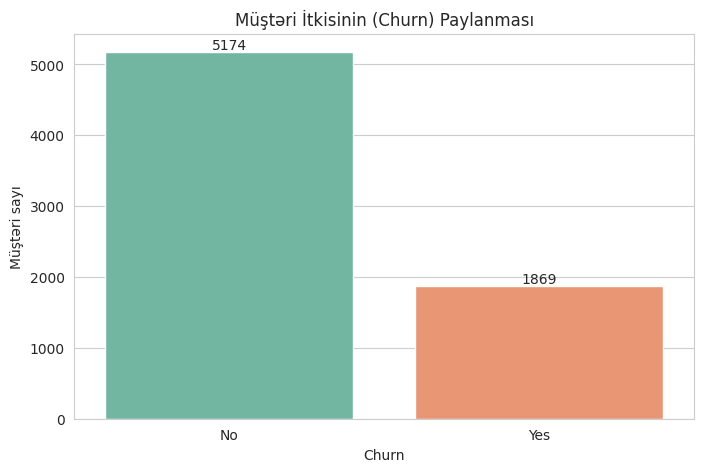

In [ ]:
plt.figure()
ax = sns.countplot(x="Churn", data=df, palette="Set2")
plt.title("Müştəri İtkisinin (Churn) Paylanması")
plt.xlabel("Churn")
plt.ylabel("Müştəri sayı")
for container in ax.containers:
    ax.bar_label(container)
plt.show()

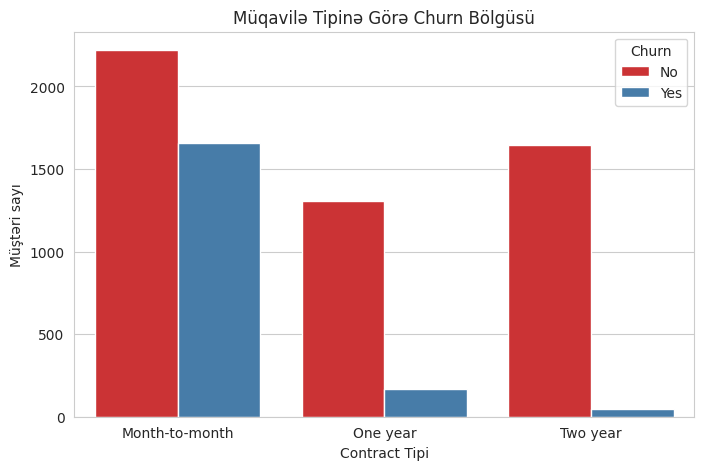

In [ ]:
if "Contract" in df.columns:
    plt.figure()
    sns.countplot(x="Contract", hue="Churn", data=df, palette="Set1")
    plt.title("Müqavilə Tipinə Görə Churn Bölgüsü")
    plt.xlabel("Contract Tipi")
    plt.ylabel("Müştəri sayı")
    plt.show()

In [ ]:
le_target = LabelEncoder()
df["Churn"] = le_target.fit_transform(df["Churn"])  # "Yes" -> 1, "No" -> 0

In [ ]:
categorical_cols = df.select_dtypes(include=["object"]).columns.tolist()
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [ ]:
X = df_encoded.drop(columns=["Churn"])
y = df_encoded["Churn"]

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [ ]:
print("Train ölçüsü:", X_train.shape)
print("Test ölçüsü:", X_test.shape)

Train ölçüsü: (5634, 30)
Test ölçüsü: (1409, 30)


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [ ]:
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [ ]:
rf_model = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=42)
rf_model.fit(X_train, y_train)

RandomForestClassifier(max_depth=8, n_estimators=200, random_state=42)

In [ ]:
print("Hər iki model uğurla öyrədildi.")


Hər iki model uğurla öyrədildi.


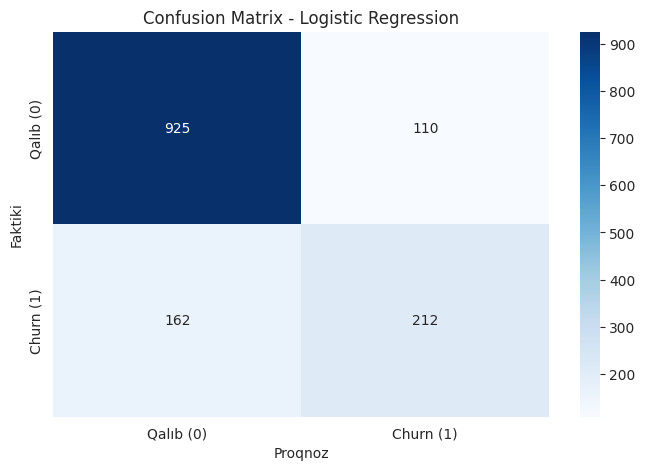

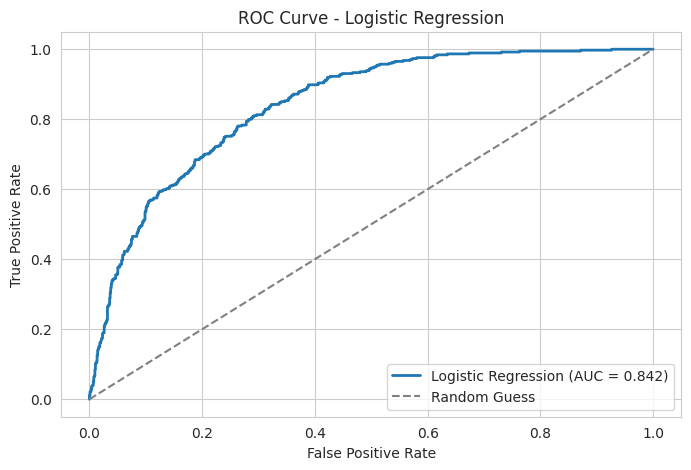


--- Logistic Regression Nəticələri ---
Accuracy    : 0.8070
Precision   : 0.6584
Recall      : 0.5668
Specificity : 0.8937
F1-score    : 0.6092
ROC AUC     : 0.8416
              precision    recall  f1-score   support

       Qalıb       0.85      0.89      0.87      1035
       Churn       0.66      0.57      0.61       374

    accuracy                           0.81      1409
   macro avg       0.75      0.73      0.74      1409
weighted avg       0.80      0.81      0.80      1409



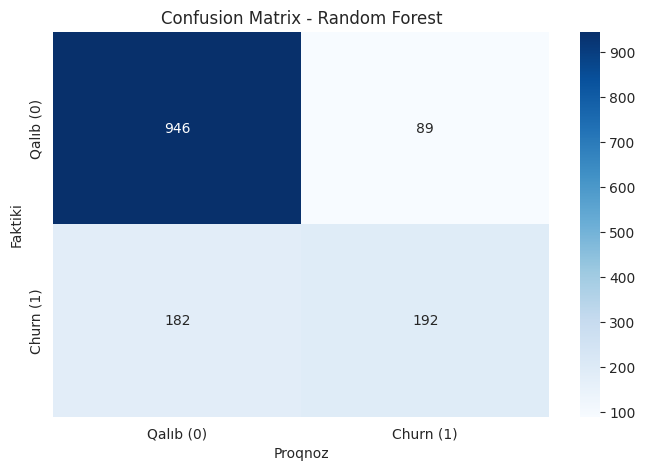

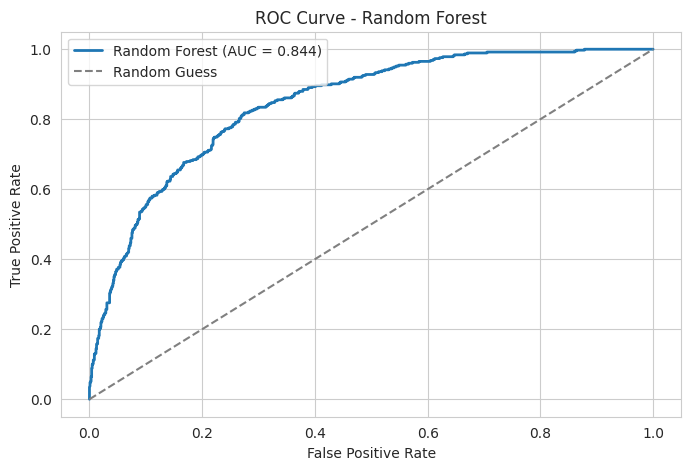


--- Random Forest Nəticələri ---
Accuracy    : 0.8077
Precision   : 0.6833
Recall      : 0.5134
Specificity : 0.9140
F1-score    : 0.5863
ROC AUC     : 0.8444
              precision    recall  f1-score   support

       Qalıb       0.84      0.91      0.87      1035
       Churn       0.68      0.51      0.59       374

    accuracy                           0.81      1409
   macro avg       0.76      0.71      0.73      1409
weighted avg       0.80      0.81      0.80      1409


=== MODEL MÜQAYİSƏ CƏDVƏLİ ===
                     Accuracy  Precision  Recall  Specificity  F1-score  \
Model                                                                     
Logistic Regression    0.8070     0.6584  0.5668       0.8937    0.6092   
Random Forest          0.8077     0.6833  0.5134       0.9140    0.5863   

                     ROC AUC  
Model                         
Logistic Regression   0.8416  
Random Forest         0.8444  


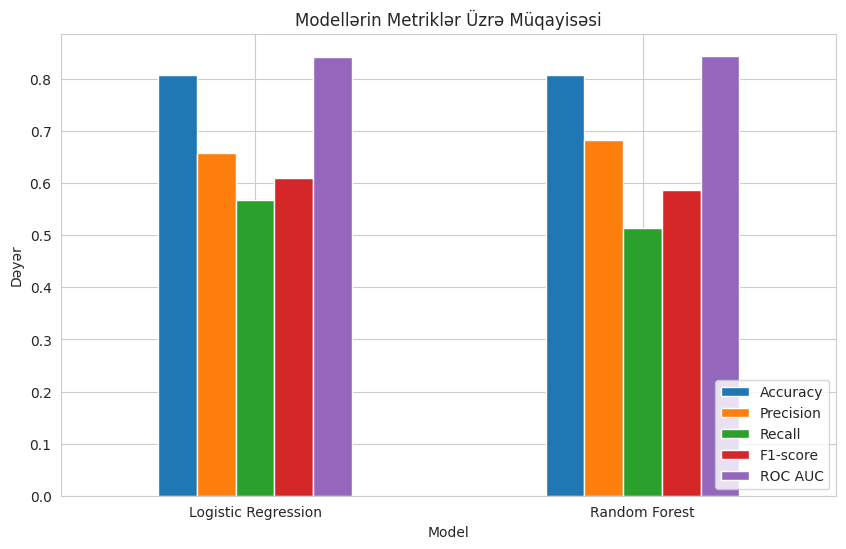

In [ ]:
def evaluate_model(model, X_test_data, y_test_data, model_name="Model"):
    """
    Verilmiş model üçün bütün əsas classification metriklərini hesablayır,
    Confusion Matrix və ROC əyrisini vizuallaşdırır.
    Nəticəni dict formasında qaytarır ki, sonda müqayisə cədvəlində istifadə edək.
    """
    y_pred = model.predict(X_test_data)
    y_proba = model.predict_proba(X_test_data)[:, 1]

    # Confusion Matrix
    cm = confusion_matrix(y_test_data, y_pred)
    tn, fp, fn, tp = cm.ravel()

    # Əsas metriklər
    accuracy = accuracy_score(y_test_data, y_pred)
    precision = precision_score(y_test_data, y_pred)
    recall = recall_score(y_test_data, y_pred)          # həmçinin Sensitivity adlanır
    specificity = tn / (tn + fp)                          # Neqativləri düzgün tanıma qabiliyyəti
    f1 = f1_score(y_test_data, y_pred)
    roc_auc = roc_auc_score(y_test_data, y_proba)

    # Confusion Matrix-in vizuallaşdırılması
    plt.figure()
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=["Qalıb (0)", "Churn (1)"],
                yticklabels=["Qalıb (0)", "Churn (1)"])
    plt.title(f"Confusion Matrix - {model_name}")
    plt.xlabel("Proqnoz")
    plt.ylabel("Faktiki")
    plt.show()

    # ROC Curve-in vizuallaşdırılması
    fpr, tpr, _ = roc_curve(y_test_data, y_proba)
    plt.figure()
    plt.plot(fpr, tpr, label=f"{model_name} (AUC = {roc_auc:.3f})", linewidth=2)
    plt.plot([0, 1], [0, 1], linestyle="--", color="gray", label="Random Guess")
    plt.title(f"ROC Curve - {model_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()

    # Nəticələrin konsola çap edilməsi
    print(f"\n--- {model_name} Nəticələri ---")
    print(f"Accuracy    : {accuracy:.4f}")
    print(f"Precision   : {precision:.4f}")
    print(f"Recall      : {recall:.4f}")
    print(f"Specificity : {specificity:.4f}")
    print(f"F1-score    : {f1:.4f}")
    print(f"ROC AUC     : {roc_auc:.4f}")
    print(classification_report(y_test_data, y_pred, target_names=["Qalıb", "Churn"]))

    return {
        "Model": model_name,
        "Accuracy": round(accuracy, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4),
        "Specificity": round(specificity, 4),
        "F1-score": round(f1, 4),
        "ROC AUC": round(roc_auc, 4)
    }


# Logistic Regression qiymətləndirilməsi (scale edilmiş data ilə)
log_results = evaluate_model(log_model, X_test_scaled, y_test, "Logistic Regression")

# Random Forest qiymətləndirilməsi
rf_results = evaluate_model(rf_model, X_test, y_test, "Random Forest")


# %%
# ==========================================================================
# 7. MODEL COMPARISON
# ==========================================================================
# Hər iki modelin nəticələrini bir cədvəldə birləşdiririk
comparison_df = pd.DataFrame([log_results, rf_results]).set_index("Model")
print("\n=== MODEL MÜQAYİSƏ CƏDVƏLİ ===")
print(comparison_df)

# Müqayisəni bar chart ilə də vizuallaşdıraq
comparison_df[["Accuracy", "Precision", "Recall", "F1-score", "ROC AUC"]].plot(
    kind="bar", figsize=(10, 6)
)
plt.title("Modellərin Metriklər Üzrə Müqayisəsi")
plt.ylabel("Dəyər")
plt.xticks(rotation=0)
plt.legend(loc="lower right")
plt.show()

In [ ]:
"""
INSIGHT (Datanın daxili analizi):
----------------------------------
Correlation matrix və "Contract tipinə görə Churn" qrafiki göstərir ki,
"Month-to-month" (aylıq) müqaviləsi olan müştərilər arasında churn nisbəti
"One year" və "Two year" müqaviləsi olanlara nisbətən əhəmiyyətli dərəcədə
yüksəkdir. Bu, uzunmüddətli öhdəlik olmadıqda müştərilərin şirkəti tərk
etmək qərarını daha asan verdiyini göstərir. Həmçinin tenure (müştərilik
müddəti) azaldıqca churn ehtimalının artması müşahidə olunur - yəni ən
kritik risk dövrü müştərinin ilk aylarıdır.

RECOMMENDATION (Biznes tövsiyəsi):
------------------------------------
Şirkət churn riskini azaltmaq üçün "Month-to-month" müqaviləsi olan və
tenure-u aşağı olan (məsələn, ilk 6 ay) müştəri seqmentinə fokuslanan
xüsusi loyallıq proqramları (endirimli 1-illik keçid təklifləri, "onboarding"
dövründə əlavə dəstək) təqdim etməlidir. Model tərəfindən yüksək churn
ehtimalı ilə işarələnən müştərilərə əvvəlcədən (proaktiv) müraciət etmək,
onları itirmədən əvvəl saxlamaq üçün ən effektiv strategiyalardan biri olardı.
"""

print("Layihə tamamlandı: Data Loading -> Cleaning -> EDA -> Split -> "
      "Training -> Evaluation -> Comparison -> Insight & Recommendation")

Layihə tamamlandı: Data Loading -> Cleaning -> EDA -> Split -> Training -> Evaluation -> Comparison -> Insight & Recommendation
